In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

%matplotlib inline

# Import FlowPDE modules
from flowpde import (
    BurgersForwardDataset, FlowDatasetWrapper,
    MLP, FlowMatching, FlowMatchingTrainer, ODEFlowSolver
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 2. Generate Dataset

First, generate the Burgers forward dataset if not already created.

In [2]:
# Check if dataset exists, if not, generate it
import os
from pathlib import Path

data_path = '../data/datasets/burgers/forward/train_32.pt'

if not Path(data_path).exists():
    print("Dataset not found. Generating Burgers forward dataset...")
    print("Run this command in terminal:")
    print("\ncd ../data/generators/burgers")
    print("python generate_forward.py --n_train 5000 --n_test 100 --resolution 128 --visualize")
    print("\nThen re-run this cell.")
else:
    print(f"Dataset found: {data_path}")

Dataset found: ../data/datasets/burgers/forward/train_32.pt


## 3. Load Dataset

**Dataset structure:**
- `input`: Initial condition u₀ (1, resolution)
- `target`: Final state u(T) (1, resolution)

In [3]:
# Load dataset
batch_size = 32

dataset = BurgersForwardDataset(
    data_path=data_path,
    normalize=True,
    return_dict=True,
    use_trajectory=False  # Only predict final state, not full trajectory
)

# Wrap for flow training (converts 'input'/'target' to 'f'/'u')
wrapped_dataset = FlowDatasetWrapper(dataset)

train_loader = DataLoader(
    wrapped_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f"Dataset size: {len(dataset)} samples")
print(f"Number of batches: {len(train_loader)}")

# Inspect sample
sample = wrapped_dataset[0]
print(f"\nSample data:")
print(f"  Initial condition (f) shape: {sample['f'].shape}")  # (1, resolution)
print(f"  Final state (u) shape: {sample['u'].shape}")        # (1, resolution)
print(f"\nViscosity: {dataset.viscosity:.4f}")
print(f"Time range: [{dataset.time[0]:.2f}, {dataset.time[-1]:.2f}]")

Dataset size: 15 samples
Number of batches: 1

Sample data:
  Initial condition (f) shape: torch.Size([1, 32])
  Final state (u) shape: torch.Size([1, 32])

Viscosity: 0.0100
Time range: [0.00, 1.00]


## 4. Visualize Data

Visualize initial conditions and corresponding final states.

Batch shapes:
  Initial conditions: torch.Size([15, 1, 32])
  Final states: torch.Size([15, 1, 32])


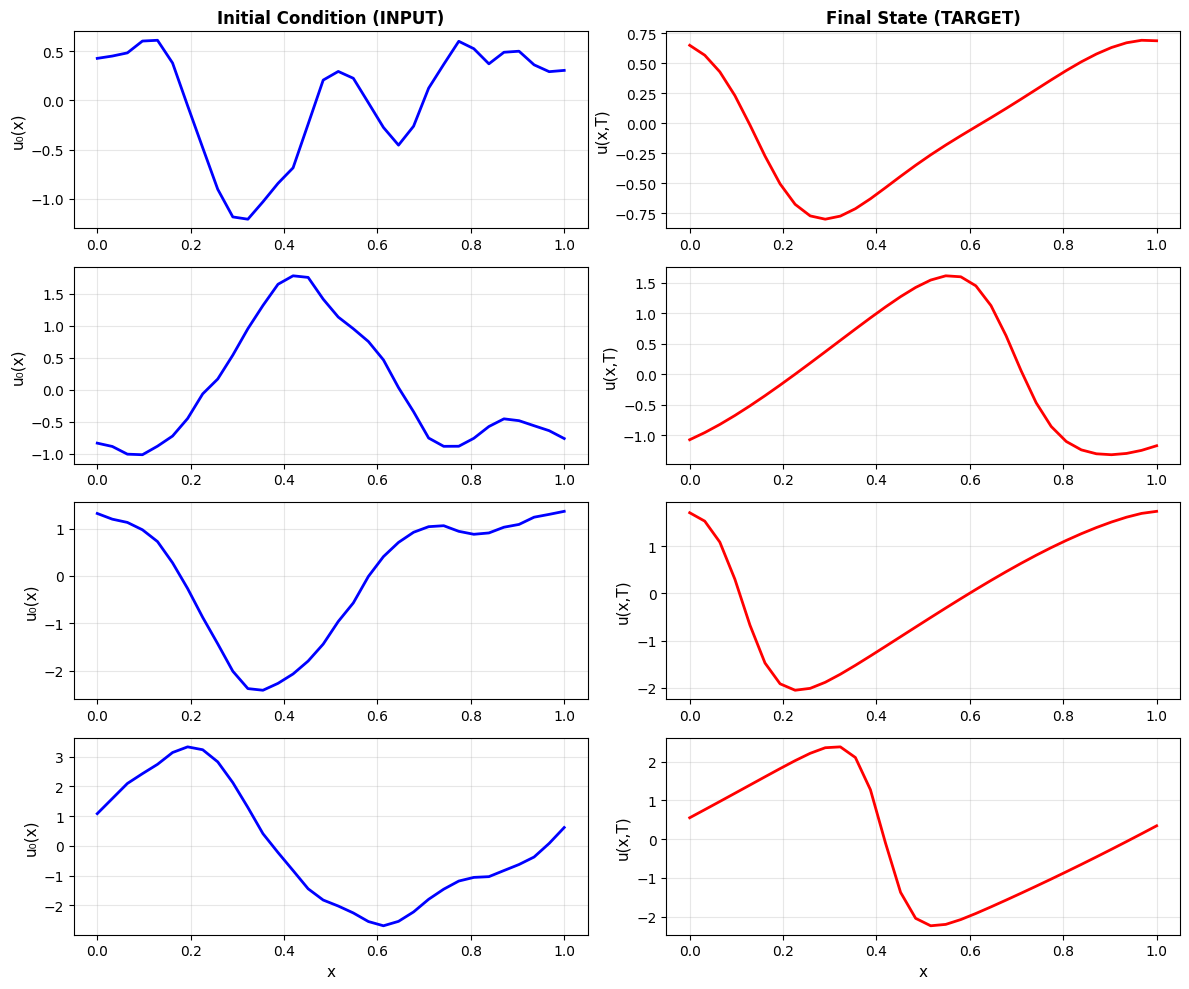

In [4]:
# Get a batch
batch = next(iter(train_loader))
initial_conditions = batch['f']  # Condition (input)
final_states = batch['u']        # Target (solution)

print(f"Batch shapes:")
print(f"  Initial conditions: {initial_conditions.shape}")  # (batch, 1, resolution)
print(f"  Final states: {final_states.shape}")              # (batch, 1, resolution)

# Visualize 4 samples
fig, axes = plt.subplots(4, 2, figsize=(12, 10))

for i in range(4):
    u0 = initial_conditions[i, 0].numpy()
    uf = final_states[i, 0].numpy()
    x = np.linspace(0, 1, len(u0))
    
    # Initial condition
    axes[i, 0].plot(x, u0, 'b-', linewidth=2)
    axes[i, 0].set_ylabel('u₀(x)', fontsize=11)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Initial Condition (INPUT)', fontweight='bold', fontsize=12)
    if i == 3:
        axes[i, 0].set_xlabel('x', fontsize=11)
    
    # Final state
    axes[i, 1].plot(x, uf, 'r-', linewidth=2)
    axes[i, 1].set_ylabel('u(x,T)', fontsize=11)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Final State (TARGET)', fontweight='bold', fontsize=12)
    if i == 3:
        axes[i, 1].set_xlabel('x', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Create Model

UNet for 1D Burgers equation (treating 1D as 2D with height=1).

In [5]:
# Model configuration
resolution = initial_conditions.shape[2]
initial_dim = initial_conditions.shape[1] * resolution  # 1 * resolution
final_dim = final_states.shape[1] * resolution          # 1 * resolution

print(f"Resolution: {resolution}")
print(f"Initial condition dimension: {initial_dim}")
print(f"Final state dimension: {final_dim}")

# Create UNet model
# Create MLP model (standard for 1D PDEs)
model = MLP(
    input_dim=final_dim,      # Solution dimension
    time_dim=1,               # Time parameter
    hidden_dim=512,           # Hidden layer size
    num_layers=6              # Number of residual blocks
)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {num_params:,}")

Resolution: 32
Initial condition dimension: 32
Final state dimension: 32

Model parameters: 3,464,224


## 6. Create Flow and Trainer

Set up Flow Matching with optimizer and scheduler.

In [6]:
# Create Flow Matching instance
flow = FlowMatching(model=model, path='linear', sigma=0.0)

# Optimizer and scheduler
learning_rate = 1e-4
epochs = 1000
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Create trainer
trainer = FlowMatchingTrainer(
    flow=flow,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)

print("Flow Matching Trainer created successfully!")
print(f"Training for {epochs} epochs with learning rate {learning_rate}")

Flow Matching Trainer created successfully!
Training for 1000 epochs with learning rate 0.0001


## 7. Train the Model

Train the flow matching model on Burgers forward problem.

In [7]:
save_dir = '../results/training/burgers_forward_notebook'

print("Starting training...")
print("="*60)

trainer.train(
    data_loader=train_loader,
    epochs=epochs,
    print_stats_interval=10,
    save_interval=20,
    save_dir=save_dir
)

print("\nTraining complete!")

Starting training...
Epoch: 0001/1000 | Train_Loss: 1.875519 | LR: 1.00e-04 | Time: 0.311847
Epoch: 0011/1000 | Train_Loss: 1.380559 | LR: 1.00e-04 | Time: 0.01686
Epoch: 0021/1000 | Train_Loss: 1.216208 | LR: 9.99e-05 | Time: 0.021082
Epoch: 0031/1000 | Train_Loss: 1.072796 | LR: 9.98e-05 | Time: 0.010865
Epoch: 0041/1000 | Train_Loss: 0.996689 | LR: 9.96e-05 | Time: 0.017561
Epoch: 0051/1000 | Train_Loss: 1.008896 | LR: 9.94e-05 | Time: 0.010064
Epoch: 0061/1000 | Train_Loss: 1.002516 | LR: 9.91e-05 | Time: 0.017074
Epoch: 0071/1000 | Train_Loss: 0.862471 | LR: 9.88e-05 | Time: 0.009717
Epoch: 0081/1000 | Train_Loss: 0.995574 | LR: 9.84e-05 | Time: 0.017088
Epoch: 0091/1000 | Train_Loss: 0.885683 | LR: 9.80e-05 | Time: 0.009692
Epoch: 0101/1000 | Train_Loss: 0.678922 | LR: 9.75e-05 | Time: 0.017066
Epoch: 0111/1000 | Train_Loss: 0.947413 | LR: 9.70e-05 | Time: 0.009801
Epoch: 0121/1000 | Train_Loss: 0.819808 | LR: 9.64e-05 | Time: 0.017009
Epoch: 0131/1000 | Train_Loss: 0.707748 | LR

## 8. Generate Samples

Use ODE solver to generate final states from initial conditions.

In [8]:
model.eval()

# Get test batch
test_batch = next(iter(train_loader))
true_initial = test_batch['f'].to(device)
true_final = test_batch['u'].to(device)

# Create ODE solver
ode_solver = ODEFlowSolver(
    model=model,
    method='dopri5',
    rtol=1e-5,
    atol=1e-7
)

# Generate samples
with torch.no_grad():
    z = torch.randn_like(true_final).to(device)
    generated_final = ode_solver.sample(
        condition=true_initial,
        x_init=z,
        n_steps=50
    )

print(f"Generated {generated_final.shape[0]} samples")
print(f"True final states range: [{true_final.min():.3f}, {true_final.max():.3f}]")
print(f"Generated final states range: [{generated_final.min():.3f}, {generated_final.max():.3f}]")

Generated 15 samples
True final states range: [-2.236, 2.385]
Generated final states range: [-2.349, 2.722]


## 9. Visualize Results

Compare true final states with generated predictions.

/var/folders/ll/tq8ksk3s1bl60rb4p7dr31f40000gn/T/ipykernel_22968/781163918.py:41: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sarperyurtseven/Desktop/sarper/.envs/pytorch/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


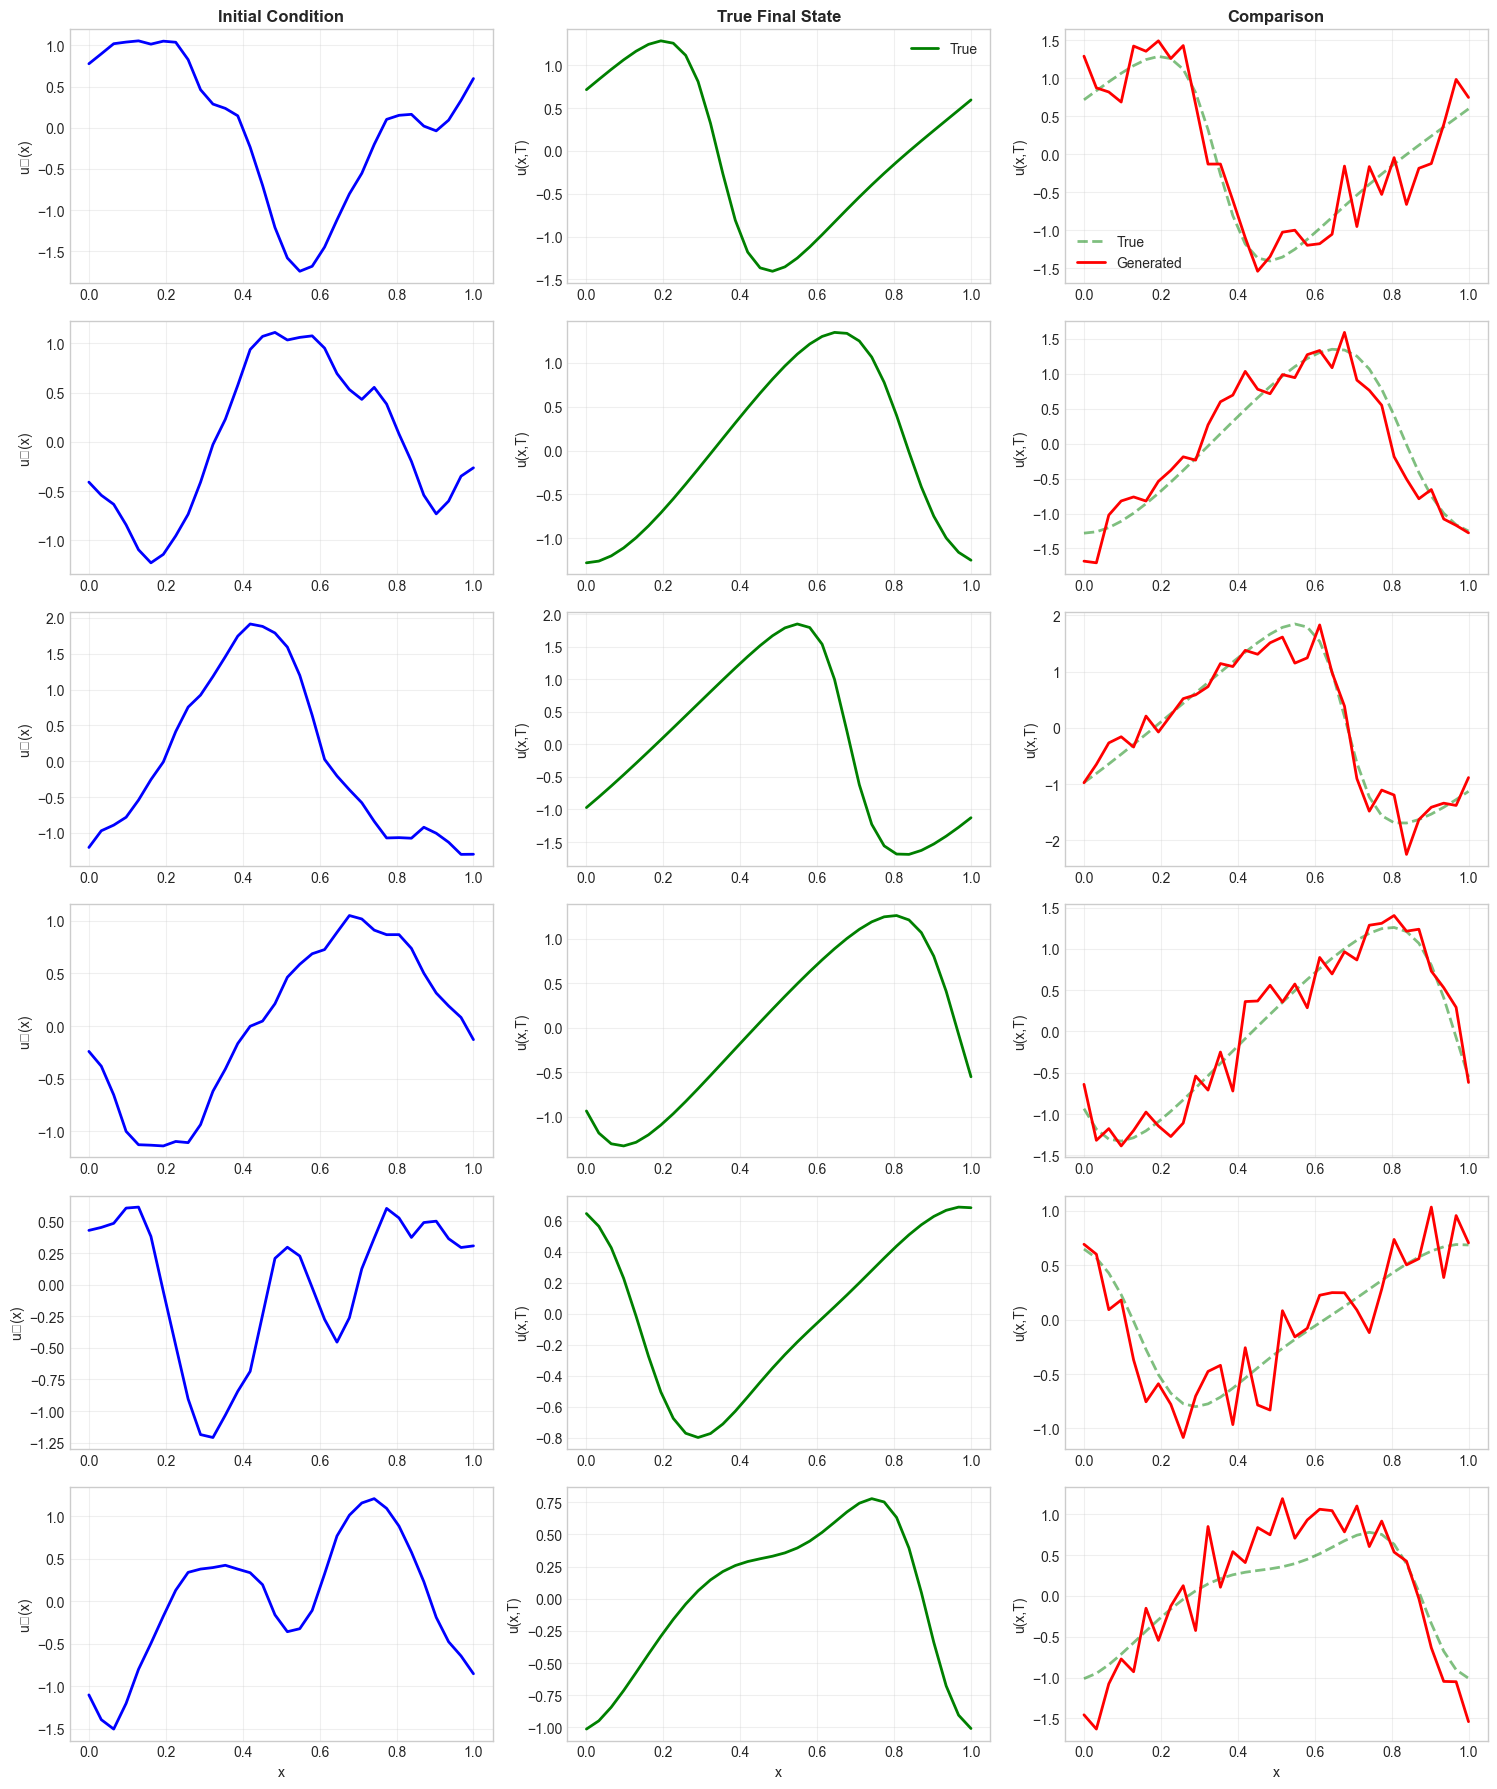


Metrics:
  MSE: 0.073029
  MAE: 0.218551


In [9]:
# Visualize comparison
num_samples = 6
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3*num_samples))

for i in range(num_samples):
    u0 = true_initial[i, 0].cpu().numpy()
    true_uf = true_final[i, 0].cpu().numpy()
    gen_uf = generated_final[i, 0].cpu().numpy()
    x = np.linspace(0, 1, len(u0))
    
    # Initial condition
    axes[i, 0].plot(x, u0, 'b-', linewidth=2)
    axes[i, 0].set_ylabel('u₀(x)', fontsize=10)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Initial Condition', fontweight='bold')
    if i == num_samples - 1:
        axes[i, 0].set_xlabel('x')
    
    # True final state
    axes[i, 1].plot(x, true_uf, 'g-', linewidth=2, label='True')
    axes[i, 1].set_ylabel('u(x,T)', fontsize=10)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('True Final State', fontweight='bold')
        axes[i, 1].legend()
    if i == num_samples - 1:
        axes[i, 1].set_xlabel('x')
    
    # Generated final state
    axes[i, 2].plot(x, true_uf, 'g--', linewidth=2, alpha=0.5, label='True')
    axes[i, 2].plot(x, gen_uf, 'r-', linewidth=2, label='Generated')
    axes[i, 2].set_ylabel('u(x,T)', fontsize=10)
    axes[i, 2].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 2].set_title('Comparison', fontweight='bold')
        axes[i, 2].legend()
    if i == num_samples - 1:
        axes[i, 2].set_xlabel('x')

plt.tight_layout()
plt.show()

# Compute metrics
mse = ((true_final - generated_final) ** 2).mean().item()
mae = (true_final - generated_final).abs().mean().item()

print(f"\nMetrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")

## 10. Uncertainty Quantification

Generate multiple predictions for the same initial condition to assess uncertainty.

/var/folders/ll/tq8ksk3s1bl60rb4p7dr31f40000gn/T/ipykernel_22968/1543931670.py:56: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


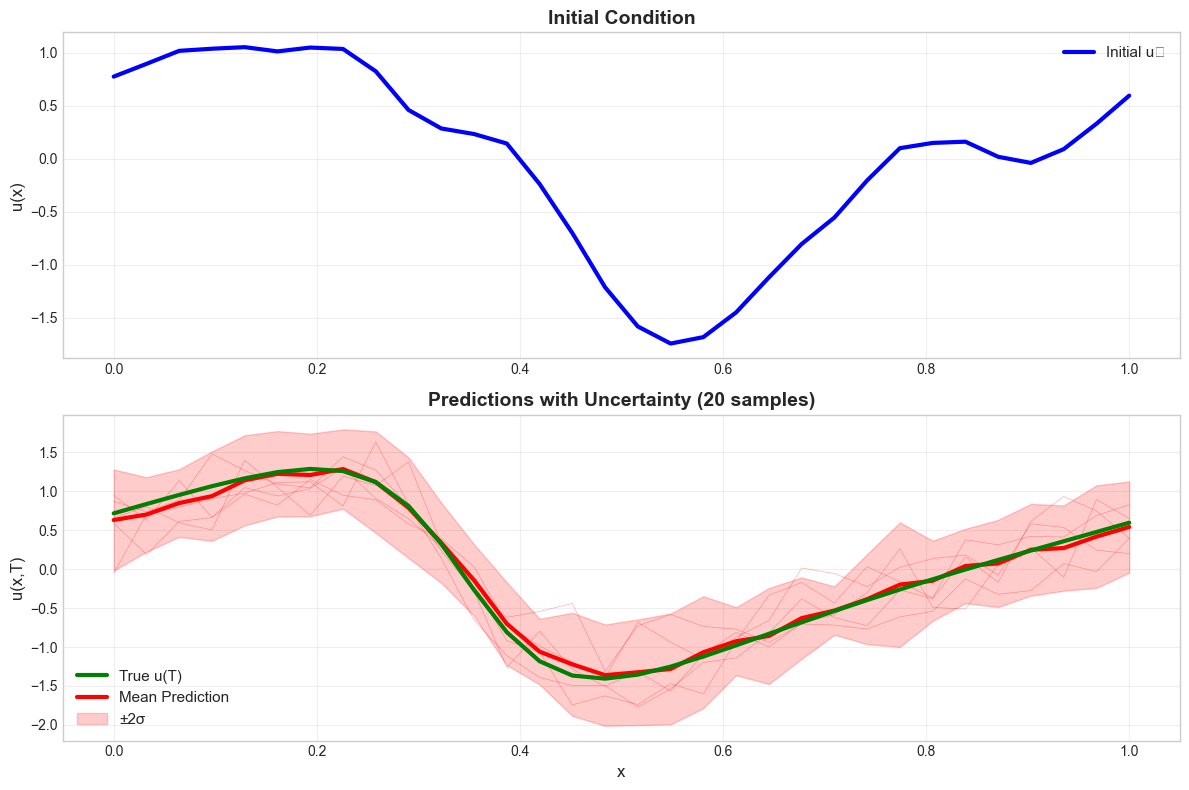


Uncertainty Quantification (from 20 samples):
  Mean Absolute Error: 0.057543
  Average Std: 0.283700
  Max Std: 0.400025


In [10]:
# Select one initial condition
idx = 0
single_initial = true_initial[idx:idx+1]
true_u = true_final[idx:idx+1]

# Generate multiple samples
num_samples_uq = 20
samples = []

with torch.no_grad():
    for _ in range(num_samples_uq):
        z = torch.randn_like(true_u)
        generated = ode_solver.sample(
            condition=single_initial,
            x_init=z,
            n_steps=50
        )
        samples.append(generated.cpu().numpy())

samples = np.array(samples).squeeze()  # (num_samples, resolution)

# Compute statistics
mean_pred = samples.mean(axis=0)
std_pred = samples.std(axis=0)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

u0 = single_initial[0, 0].cpu().numpy()
true_uf = true_u[0, 0].cpu().numpy()
x = np.linspace(0, 1, len(u0))

# Initial condition
axes[0].plot(x, u0, 'b-', linewidth=3, label='Initial u₀')
axes[0].set_ylabel('u(x)', fontsize=12)
axes[0].set_title('Initial Condition', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Predictions with uncertainty
axes[1].plot(x, true_uf, 'g-', linewidth=3, label='True u(T)', zorder=10)
axes[1].plot(x, mean_pred, 'r-', linewidth=3, label='Mean Prediction', zorder=9)
axes[1].fill_between(x, mean_pred - 2*std_pred, mean_pred + 2*std_pred, 
                     color='red', alpha=0.2, label='±2σ')

# Plot individual samples
for i in range(min(5, num_samples_uq)):
    axes[1].plot(x, samples[i], 'r-', linewidth=0.5, alpha=0.3)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('u(x,T)', fontsize=12)
axes[1].set_title(f'Predictions with Uncertainty ({num_samples_uq} samples)', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nUncertainty Quantification (from {num_samples_uq} samples):")
print(f"  Mean Absolute Error: {np.abs(true_uf - mean_pred).mean():.6f}")
print(f"  Average Std: {std_pred.mean():.6f}")
print(f"  Max Std: {std_pred.max():.6f}")